# 2. Tree visualization

Draw your annotated cells on the cell ontology — the reference family tree of
cell types HECTOR predicts into — in two layouts.

Tutorial 01 produced a table of labels. A table tells you *what* was found; it
does not show how the findings relate to one another. This tutorial puts the
same labels on the tree that defines those relationships, so related cell types
sit together and each population's size is visible at a glance.

Two layouts are available, and choosing between them is the subject of this
tutorial:

* **horizontal** — the tree runs left to right, root at the left, all text
  upright, lineages in parallel bands. It reads like a diagram.
* **radial** — the tree fans out from a centre point. Each lineage owns a wedge
  of the circle, which is what fits a large tree into a square figure.

Everything else is the same call with one argument changed.

## Getting the data

We use the same public 10x Genomics dataset as tutorial 01's quick start —
about 1,000 human blood cells. The download is roughly 10 MB and happens once.

In [1]:
import pathlib
import shutil
import tarfile
import urllib.request

URL = ("https://cf.10xgenomics.com/samples/cell-exp/3.0.0/"
       "pbmc_1k_v3/pbmc_1k_v3_filtered_feature_bc_matrix.tar.gz")

if not pathlib.Path("filtered_feature_bc_matrix").exists():
    request = urllib.request.Request(URL, headers={"User-Agent": "hector-tutorial"})
    with urllib.request.urlopen(request) as response, \
            open("pbmc_1k_v3.tar.gz", "wb") as handle:
        shutil.copyfileobj(response, handle)
    with tarfile.open("pbmc_1k_v3.tar.gz") as archive:
        archive.extractall(".")

## Step 1. Annotate the cells

Three lines, exactly as in tutorial 01. If you already have an annotated
`.h5ad` file, load it instead and skip this step — anything that has been
through `predict()` and `write_predictions()` works here.

In [2]:
import hector

adata = hector.load_cellranger_data("filtered_feature_bc_matrix")
predictor = hector.HECTOR("human")
predictions = predictor.predict(adata, label_format="name")
predictor.write_predictions(adata, predictions)

adata.obs["hector_prediction"].value_counts().head(8)

  ✅ Found data in: filtered_feature_bc_matrix


  ✅ Loaded: 1222 cells x 33538 genes


<environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded


  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully! 🥳
   Prediction hardware: GPU (Apple M1 Max, MLX)
   Supported cell types: 1407
  [INFO] Making predictions on 1222 cells...
  Settings: top_k=1, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...
  Gene matching: 4978/5000 (99.6% of reference genes found)
  Step 2: Processing expression data...


...

  [INFO] Applying GRIT refinement...

  GRIT REFINEMENT
  Metric          Min      5%       25%      Median   75%      95%      Max     
  ---------------------------------------------------------------------------
  Entropy         2.58     2.70     2.83     2.99     3.21     3.42     3.88    
  ---------------------------------------------------------------------------

  [Auto-Thresholding]: Detected Threshold: 3.2348. Refining the lower 22.1% of the prediction distribution

  Step 4: Refining 270 cells using all 1,222 cells as neighbors ...


  kNN graph:   0%|                                      | 0/1 [00:00<?, ?tile/s]

  kNN graph: 100%|██████████████████████████████| 1/1 [00:00<00:00, 41.98tile/s]

  ✅ Predictions complete!
  Step 5: Formatting results...
  ✅ Results formatted as DataFrame with shape (1222, 3)
  Rare-cell rollup summary: threshold=13 cells (min(1.0% of 1222, 20)), 47 type(s) bucketed as 'Rare Cells', 122 cell(s) affected
  Annotated adata.obs with 5 columns (prefix='hector_', 1222/1222 cells matched)


hector_prediction
classical monocyte                                         296
CD4-positive, alpha-beta memory T cell, CD45RO-positive    106
naive thymus-derived CD4-positive, alpha-beta T cell       105
naive B cell                                                96
mucosal invariant T cell                                    66
natural killer cell                                         49
effector memory CD4-positive, alpha-beta T cell             45
naive thymus-derived CD8-positive, alpha-beta T cell        38
Name: count, dtype: int64

## Step 2. The horizontal layout

One call. The tree covers only the cell types your data actually contains, not
all 1,407 the model knows — a tree of everything would be unreadable and mostly
empty.

`label_format="name"` prints readable names such as `classical monocyte` rather
than ontology identifiers such as `CL:0000860`.

In [3]:
hector.create_trajectory_analysis(
    predictor=predictor,
    adata=adata,
    output_file="02_tree_horizontal.pdf",
    title="PBMC 1k — horizontal layout",
    layout_mode="horizontal",
    label_format="name",
)

[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

HECTOR Tree Visualization
Unity Mode: GRIT=On
Label Format: name
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 1222 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.


[INFO] Pruning cell types below 20 cells: 51 cell types removed.
[INFO] Starting Trajectory Analysis...


[INFO] Layout pipeline: Using PURE ontology DAG
[INFO] Visual pipeline: Building visual edges


[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
  > Tagged 202 Transitioning Typical, 854 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 1056 | Nodes: 31 | Edges: 35 (inferred paths: 0)
Plot generating......


✅ Saved: 02_tree_horizontal.pdf


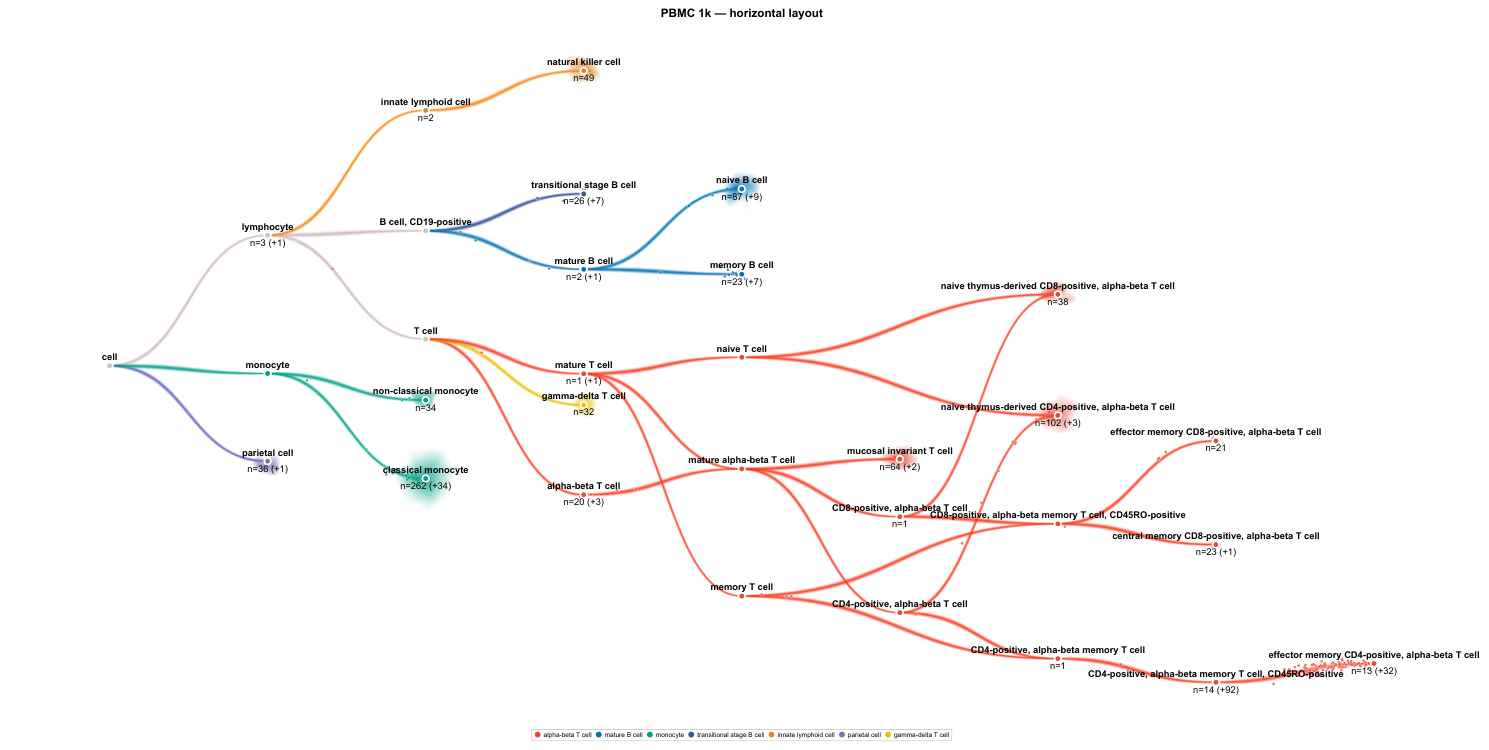

What the picture contains:

* **Each labelled point is a cell type**, placed where it sits in the ontology.
  A type's parent is always to its left, so the tree reads outward from `cell`
  through `lymphocyte` to the specific types.
* **Each small dot is one of your cells**, drawn near the type it was assigned
  to.
* **Cloud size** scales with the number of cells at a type, so the common
  populations show up as the largest blooms before you read any label.
* **Colour** groups branches by lineage: T cells one family of colours, B cells
  another, monocytes another.
* **`n=262 (+34)`**, under `classical monocyte`, means 262 cells were drawn in
  that type's cloud, and a further 34 cells belonging to that type were drawn
  out along branches instead. Step 5 explains the second number.

**Branch thickness carries no information.** Branches simply taper from thick
at the root to thin at the tips so the tree is easy to follow; the width is
decoration, not data. Read population size from the clouds and the `n=` labels.

## Step 3. The radial layout

The same data and the same call, with `layout_mode="radial"`.

In [4]:
hector.create_trajectory_analysis(
    predictor=predictor,
    adata=adata,
    output_file="02_tree_radial.pdf",
    title="PBMC 1k — radial layout",
    layout_mode="radial",
    label_format="name",
)

[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

HECTOR Tree Visualization
Unity Mode: GRIT=On
Label Format: name
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 1222 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.


[INFO] Pruning cell types below 20 cells: 51 cell types removed.
[INFO] Starting Trajectory Analysis...


[INFO] Layout pipeline: Using PURE ontology DAG
Converting DAG to Strict Tree for Radial Layout...
[INFO] Visual pipeline: Building visual edges
[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
  > Tagged 203 Transitioning Typical, 852 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 1055 | Nodes: 32 | Edges: 31 (inferred paths: 0)
Plot generating......


✅ Saved radial tree: 02_tree_radial.pdf


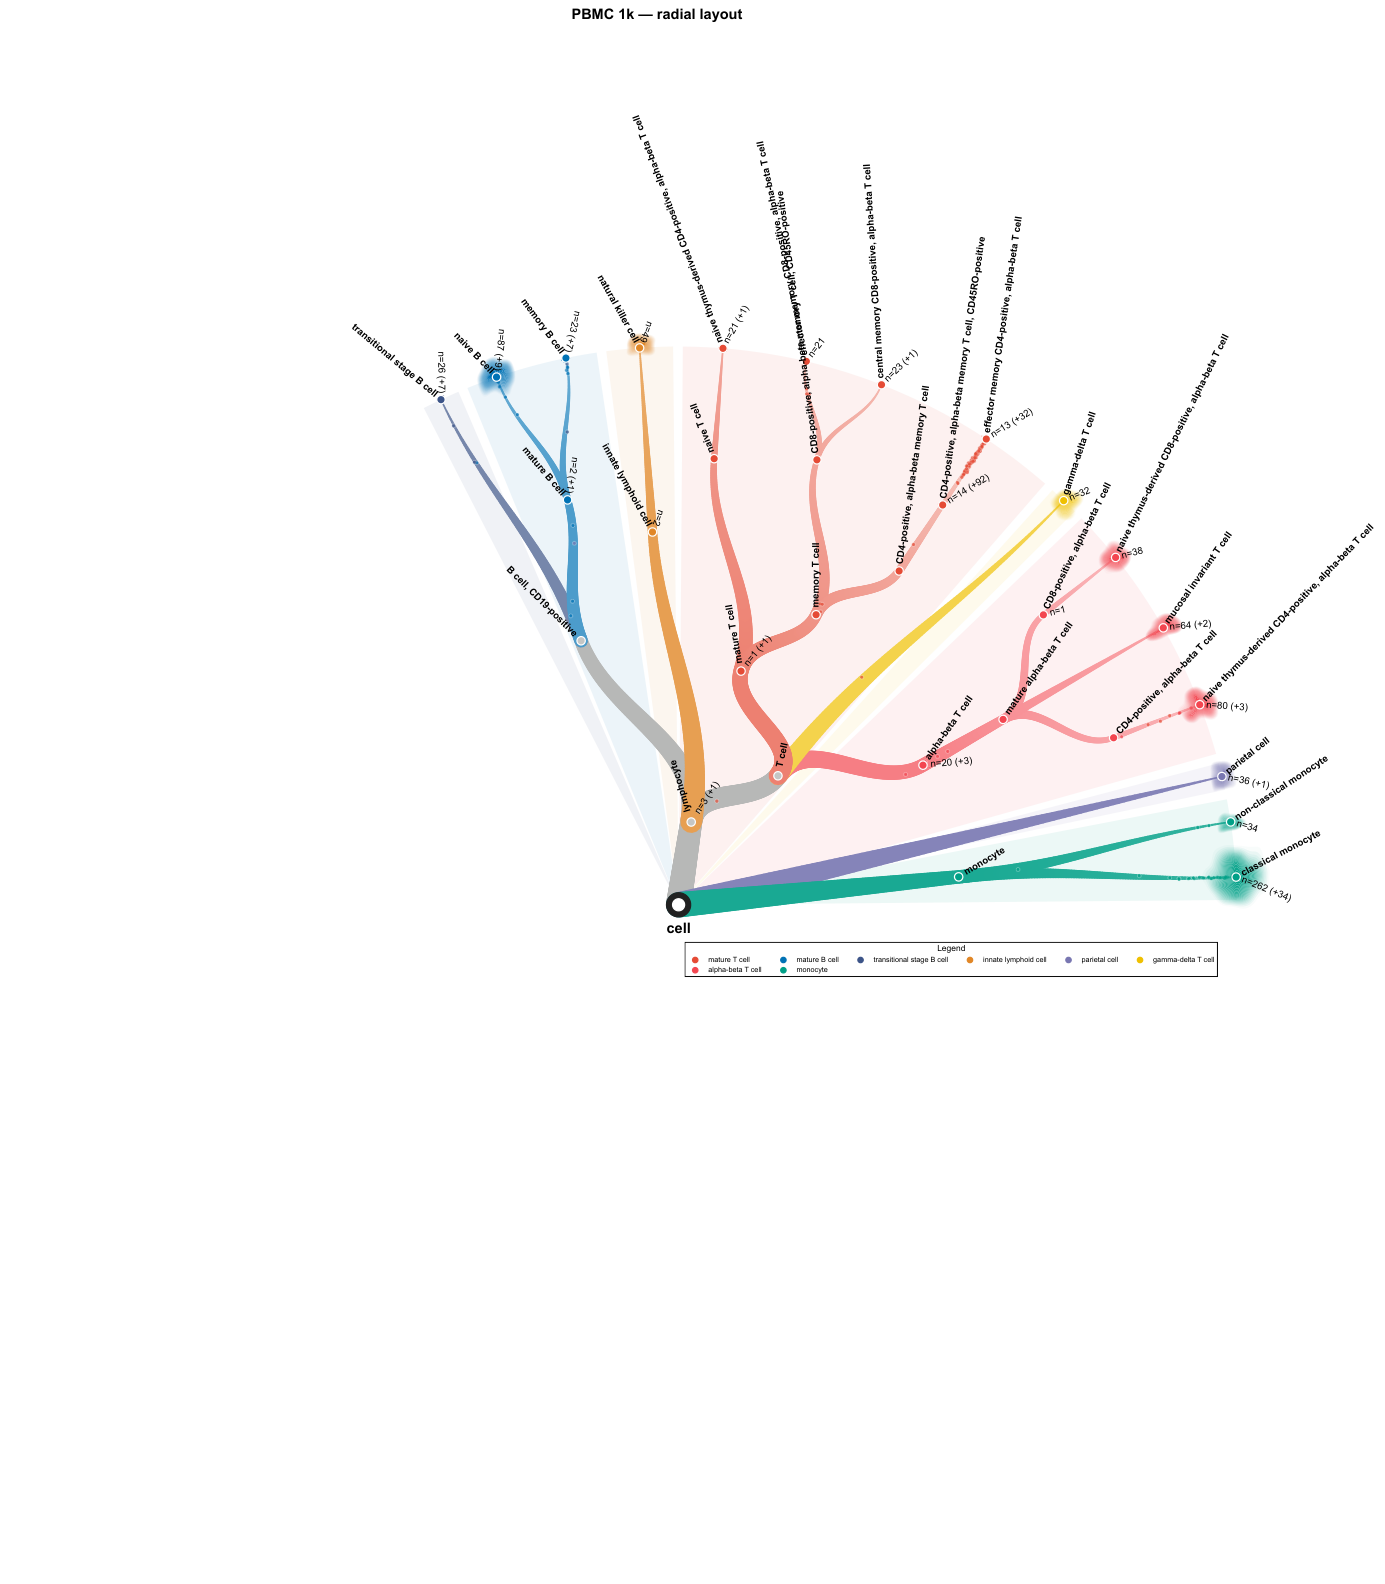

The fan is a wedge rather than a full circle, and that is on purpose: the
spread grows with the size of the tree, from about 40° for a handful of types
up to 240° for a large one. A small tree gets a narrow fan because spreading it
further would add space without adding information. The page around it stays
the same size whatever the tree, so a small dataset leaves a wide margin — crop
it if it bothers you.

The one reason to override this is crowding: if a lineage has so many types
that their labels collide at the outer rim, `radial_sweep_angle_degrees` widens
the fan and gives them room.

## Step 4. Which layout to use

| | horizontal | radial |
| --- | --- | --- |
| shape | wide and short | square |
| text | always upright | rotates with the branch |
| lineages | parallel bands, easy to follow | wedges around a circle |
| few cell types | reads cleanly, fills the page | narrow fan, wide page margin |
| many cell types | needs a much larger canvas | absorbs them without tuning |

**On a dataset with around a hundred cell types the tuning goes the other
way.** Radial absorbs them without adjustment; horizontal collides with itself
on the default page, and the fix is more room rather than fewer cells:
`pdf_figsize` sets the page size in inches, `y_scale` how far apart branches
are stacked, and `x_scale` how far apart the levels sit. Raise all three
together. For the interactive output the equivalent settings are
`html_plot_width` and `html_plot_height`, in pixels.

**They are not two drawings of the same tree.** The ontology is a *graph*, not
a strict tree: some cell types have more than one parent. The horizontal layout
draws that as it is. The radial layout needs each lineage to own an unbroken
wedge, so any multi-parent type is duplicated — once under each parent — and
its cells go to whichever copy fits them better. Expect small differences in
the per-type counts between the two layouts.

**File formats.** The extension decides the output. `.pdf` gives a static
figure. `.html` gives the same figure as an interactive page you can pan, zoom
and hover over in a browser — the better choice when a static figure is too
crowded to read.

In [5]:
hector.create_trajectory_analysis(
    predictor=predictor,
    adata=adata,
    output_file="02_tree_radial.html",
    title="PBMC 1k — radial layout, interactive",
    layout_mode="radial",
    label_format="name",
)

[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

HECTOR Tree Visualization
Unity Mode: GRIT=On
Label Format: name
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 1222 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.


[INFO] Pruning cell types below 20 cells: 51 cell types removed.
[INFO] Starting Trajectory Analysis...


[INFO] Layout pipeline: Using PURE ontology DAG
Converting DAG to Strict Tree for Radial Layout...
[INFO] Visual pipeline: Building visual edges


[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
  > Tagged 203 Transitioning Typical, 852 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 1055 | Nodes: 32 | Edges: 31 (inferred paths: 0)
Plot generating......


✅ Saved radial HTML: 02_tree_radial.html


## Step 5. Reading the clouds

Not every cell is drawn sitting on its labelled type. Many sit part of the way
along a branch, between a general type and one of its own subtypes. These are
the cells counted by the `(+34)` part of a node's label, and marked
`Transitioning` in the table below.

**That distance measures how decisively a cell matched the subtype. It is not
movement between cell types.** The branches here are "is a" relationships taken
from the cell ontology: a classical monocyte *is a* monocyte. Nothing travels
along such a branch, because nothing turns from a monocyte into a classical
monocyte — a cell either is one, or the evidence was not decisive enough to say
so.

The spread is still informative, because populations that genuinely form a
continuum produce more of it. In this dataset most of it sits on one branch, in
the CD4 memory T cells — and that is exactly where blood biology is continuous,
running from naive through central memory to effector memory with no natural
breaks. When a classifier must pick one label per cell for a population with no
sharp internal boundaries, its confidence drops and its cells spread along the
branch. That is the model reporting the biology accurately, not failing.

Populations that really are discrete behave the other way: the non-classical
monocytes sit tightly on their node.

## Step 6. The columns it writes

Drawing the figure also records where each cell was placed, so the positions
can be worked with and not only looked at.

In [6]:
adata.obs["trajectory_state"].value_counts(dropna=False)

trajectory_state
Stable           852
Transitioning    203
Pruned           167
Name: count, dtype: int64

* **`trajectory_state`** — `Stable` for a cell sitting at a type,
  `Transitioning` for one partway along a branch, `Pruned` for a cell whose
  type was dropped from the figure (Step 7).
* **`trajectory_source`** and **`trajectory_target`** — the two cell types at
  the ends of the branch the cell was placed on.
* **`relative_position`** — where along that branch it sits, 0 at the
  source and 1 at the target. Defined for every cell.
* **`transition_position`** — the same measure for `Transitioning` cells only,
  rescaled to fill 0 to 1, and 0 for stable cells.

Use `relative_position` when comparing positions across all cells, since
it is the one that is defined everywhere.

In [7]:
adata.obs.loc[
    adata.obs["trajectory_state"] == "Transitioning",
    ["trajectory_source", "trajectory_target"],
].value_counts().head(8)

trajectory_source                                        trajectory_target                                   
CD4-positive, alpha-beta memory T cell, CD45RO-positive  effector memory CD4-positive, alpha-beta T cell         115
monocyte                                                 classical monocyte                                       33
CD4-positive, alpha-beta T cell                          naive thymus-derived CD4-positive, alpha-beta T cell     11
mature B cell                                            memory B cell                                             8
                                                         naive B cell                                              7
B cell, CD19-positive                                    transitional stage B cell                                 6
                                                         mature B cell                                             4
CD8-positive, alpha-beta memory T cell, CD45RO-positive  effector memor

Read these pairs as "cells that look like a *source* without decisively
matching *target*" — not as one type becoming another.

## Step 7. Rare types are pruned

By default a cell type needs at least 20 of your cells before it is drawn.
Types below that are removed and their cells marked `Pruned` — on this dataset
that is 51 of the types the model proposed.

This is deliberate. A handful of cells scattered over dozens of rare types adds
branches carrying no reliable signal and crowds out the ones that do.

The threshold is a real trade-off, not a free simplification. Raising it to 50
on a dataset this small removes another third of the cells from the figure, so
raise it only when the tree is too busy to read, and lower it when you are
specifically hunting a small population.

In [8]:
hector.create_trajectory_analysis(
    predictor=predictor,
    adata=adata,
    output_file="02_tree_radial_min50.pdf",
    title="PBMC 1k — types with at least 50 cells",
    layout_mode="radial",
    label_format="name",
    min_cells_number=50,
)

[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.

HECTOR Tree Visualization
Unity Mode: GRIT=On
Label Format: name
[INFO] Extracting visualization vectors (Unity Mode: GRIT=On)...
[INFO] Processing 1222 cells...
[INFO] Reusing cached predictions from adata.uns['hector_prediction_core_manifest'] (same cells, same settings). Pass force_recompute=True to recompute.


[INFO] Pruning cell types below 50 cells: 62 cell types removed.
[INFO] Starting Trajectory Analysis...


[INFO] Layout pipeline: Using PURE ontology DAG
Converting DAG to Strict Tree for Radial Layout...
[INFO] Visual pipeline: Building visual edges
[HECTOR] auto-detected stable_source_zone=0.2000, stable_target_zone=0.2000  (mode=fallback)
  > Tagged 150 Transitioning Typical, 556 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 706 | Nodes: 16 | Edges: 15 (inferred paths: 0)
Plot generating......


✅ Saved radial tree: 02_tree_radial_min50.pdf


## Where next

Tutorial 03 draws this same tree once per group — treated against control, one
donor against another — on a shared layout, so differences in composition line
up side by side instead of having to be held in your head.